In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Putting it all together 
### Associated lectures: All material till lecture 13 

<div class="alert-warning">
    
## Instructions  
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Before you start  

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
  
- Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   
### Before submitting  

- **Run all cells** (▶▶ button) to ensure the notebook executes cleanly from top to bottom.

  - Execution counts must start at **1** and be sequential.
    
  - Notebooks with missing outputs or errors may lose marks.

- **Do not upload or push data files** used in this lab to GitHub or Gradescope. (A `.gitignore` is provided to prevent this.)  


### Submitting on Gradescope  

- Upload **only** your `.ipynb` file (with outputs shown) and any required output files. Do **not** submit extra files.
  
- If needed, refer to the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- If your notebook is too large to render, also upload a **Web PDF** or **HTML** version.  
  - You can create one using **File $\rightarrow$ Save and Export Notebook As**.  
  - If you get an error when creating a PDF, try running the following commands in your lab directory:  

    ```bash
    conda install -c conda-forge nbconvert-playwright
    jupyter nbconvert --to webpdf lab1.ipynb
    ```  

  - Ensure all outputs are visible in your PDF or HTML file; TAs cannot grade your work if outputs are missing.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [2]:
from hashlib import sha1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score, classification_report
import shap

<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

In this mini project, you have the option to choose on which dataset you will be working on. The tasks you will need to carry on will be similar, independently of your choice.

### Option 1
You can choose to work on a classification problem of predicting whether a credit card client will default or not. 
For this problem, you will use [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). In this data set, there are 30,000 examples and 24 features, and the goal is to estimate whether a person will default (fail to pay) their credit card bills; this column is labeled "default.payment.next.month" in the data. The rest of the columns can be used as features. You may take some ideas and compare your results with [the associated research paper](https://www.sciencedirect.com/science/article/pii/S0957417407006719), which is available through [the UBC library](https://www.library.ubc.ca/). 


### Option 2
You can choose to work on a regression problem using a [dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) of New York City Airbnb listings from 2019. As usual, you'll need to start by downloading the dataset, then you will try to predict `reviews_per_month`, as a proxy for the popularity of the listing. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts create more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features were are using in `listings.csv.gz` for the New York city datasets. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.


<div class="alert alert-info">
    
**Your tasks:**

1. Review the available datasets and choose the one you find most interesting. It may help to read through the dataset documentation on Kaggle before deciding.
2. Once you've selected a dataset, take time to understand the problem it represents and the meaning of each feature. Use the Kaggle documentation to guide you.
3. Download the dataset and load it into a pandas DataFrame.
4. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>

<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

In this project, we aim to predict whether a credit card client will default on their next payment.

This is a **binary classification problem** where:

Target variable: `default payment next month`
- 0 = No default
- 1 = Default

The goal is to build a supervised learning model that predicts the probability of default using demographic and financial attributes such as credit limit, bill amounts, and payment history.
Accurate default prediction is important because it helps financial institutions assess credit risk and make informed lending decisions.

In [3]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [4]:
df = pd.read_csv("UCI_Credit_Card.csv")
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

X = df.drop(columns=["default.payment.next.month"])
y = df["default.payment.next.month"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=123,
    stratify=y 
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (21000, 23)
Test shape: (9000, 23)


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [5]:
y_train.value_counts()
y_train.value_counts(normalize=True)

default.payment.next.month
0    0.77881
1    0.22119
Name: proportion, dtype: float64

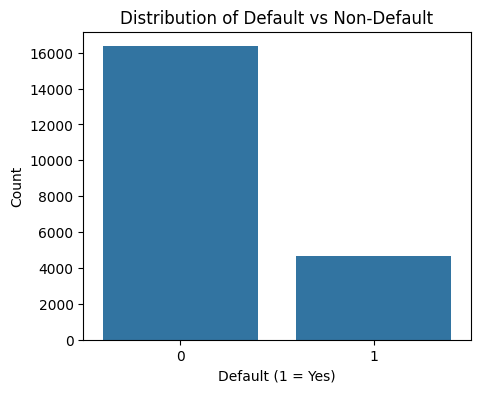

In [6]:
plt.figure(figsize=(5,4))
sns.countplot(x=y_train)
plt.title("Distribution of Default vs Non-Default")
plt.xlabel("Default (1 = Yes)")
plt.ylabel("Count")
plt.show()

### Class Distribution

The bar plot shows that non-default cases significantly outnumber default cases. 

Approximately 78% of clients did not default, while 22% defaulted. The minority class (default) is substantially smaller.

This suggests that:
- Accuracy alone may overestimate model performance.
- Stratified splitting is necessary.
- ROC-AUC or F1-score may be more appropriate evaluation metrics.

In [7]:
X_train[["LIMIT_BAL", "AGE"]].describe()
X_train[[f"BILL_AMT{i}" for i in range(1,7)] + [f"PAY_AMT{i}" for i in range(1,7)]].describe().T

,count,mean,std,min,25%,50%,75%,max
BILL_AMT1,21000.0,50978.436286,73097.849892,-154973.0,3517.75,22485.5,67061.25,964511.0
BILL_AMT2,21000.0,48967.398286,70519.344263,-69777.0,2947.75,21404.5,64088.00,983931.0
BILL_AMT3,21000.0,46977.104857,69264.718750,-157264.0,2666.25,20138.0,60630.00,1664089.0
BILL_AMT4,21000.0,43295.839476,64297.470511,-170000.0,2318.75,19119.5,54928.75,891586.0
BILL_AMT5,21000.0,40389.043095,60866.714551,-28335.0,1776.00,18160.5,50229.75,927171.0
BILL_AMT6,21000.0,38838.993143,59587.880749,-339603.0,1315.75,17094.5,49286.25,961664.0
PAY_AMT1,21000.0,5663.359190,16612.876887,0.0,1000.00,2100.0,5001.00,873552.0
PAY_AMT2,21000.0,5990.677238,25088.475221,0.0,855.75,2010.5,5000.00,1684259.0
PAY_AMT3,21000.0,5214.520762,18035.872826,0.0,390.00,1800.0,4529.25,896040.0
PAY_AMT4,21000.0,4876.729810,16423.808259,0.0,300.00,1500.0,4000.00,621000.0


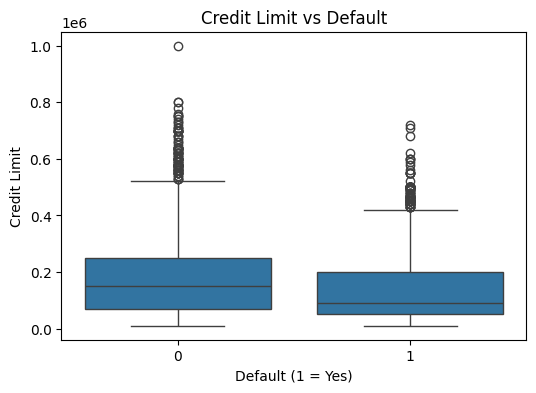

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x=y_train, y=X_train["LIMIT_BAL"])
plt.title("Credit Limit vs Default")
plt.xlabel("Default (1 = Yes)")
plt.ylabel("Credit Limit")
plt.show()

### Numerical Feature Observations

The bill amount variables (`BILL_AMT1–6`) show:

- Large ranges (up to 964,511  dollars)
- High standard deviations
- Have negative value
- Right-skewed distributions with extreme outliers

Similarly, payment amount variables (`PAY_AMT1–6`) exhibit:

- Median values significantly smaller than the mean
- Large maximum values (168,425 NT dollars)
- Strong right skew

These characteristics indicate that scaling is necessary.

## From EDA

Based on the exploratory data analysis, several observations can be made:

1. The target variable is moderately imbalanced, with approximately 78% non-default cases and 22% default cases. While not extreme, this imbalance suggests that evaluation metrics beyond accuracy should be considered.

2. Continuous financial variables such as `LIMIT_BAL`, `BILL_AMT1–6`, and `PAY_AMT1–6` exhibit large ranges and strong right skewness, with substantial outliers. This indicates high variability in customer financial behavior.

3. The credit limit distribution differs between default and non-default cases. Clients who default generally have lower median credit limits, suggesting that credit capacity may be related to default risk.

4. Repayment status variables (`PAY_0–PAY_6`) are ordinal and likely highly informative, as delayed payments logically increase default risk.

## Evaluation Metrics

Given the moderate class imbalance, accuracy alone would not be an appropriate metric, as a model could achieve high accuracy by simply predicting the majority class.

Therefore, we will use:

- **ROC-AUC**  
- **Precision and Recall**, since in credit risk prediction, identifying defaulters (true positives) is particularly important.
- **F1-score**, which balances precision and recall.

Using these metrics provides a more comprehensive assessment of predictive performance than accuracy alone.

In [9]:
...

Ellipsis

In [10]:
...

Ellipsis

In [11]:
...

Ellipsis

In [12]:
...

Ellipsis

In [13]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

In [14]:
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
pay_cols  = [f"PAY_AMT{i}" for i in range(1, 7)]
delay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

for X in [X_train, X_test]:
    X["avg_bill_amt"] = X[bill_cols].mean(axis=1)
    X["avg_pay_amt"]  = X[pay_cols].mean(axis=1)
    X["avg_delay"]    = X[delay_cols].mean(axis=1)

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

In [15]:
numeric_features = [
    "LIMIT_BAL", "AGE",
    "PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6",
    "BILL_AMT1","BILL_AMT2","BILL_AMT3",
    "BILL_AMT4","BILL_AMT5","BILL_AMT6",
    "PAY_AMT1","PAY_AMT2","PAY_AMT3",
    "PAY_AMT4","PAY_AMT5","PAY_AMT6",
    "avg_bill_amt","avg_pay_amt","avg_delay"
]

categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [16]:
...

Ellipsis

In [17]:
...

Ellipsis

In [18]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [19]:
baseline_model = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

baseline_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)
print("Baseline ROC-AUC (mean):", baseline_scores.mean())
print("Baseline ROC-AUC (std):", baseline_scores.std())

Baseline ROC-AUC (mean): 0.5
Baseline ROC-AUC (std): 0.0


In [20]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [21]:
log_reg = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000))
])
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}
grid_log = GridSearchCV(
    log_reg,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
grid_log.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=5000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

In [22]:
cv_results = grid_log.cv_results_
best_idx = grid_log.best_index_

mean_score = cv_results["mean_test_score"][best_idx]
std_score  = cv_results["std_test_score"][best_idx]

print("Mean ROC-AUC:", mean_score)
print("Std ROC-AUC:", std_score)

Mean ROC-AUC: 0.7211964818532828
Std ROC-AUC: 0.011148427260430168


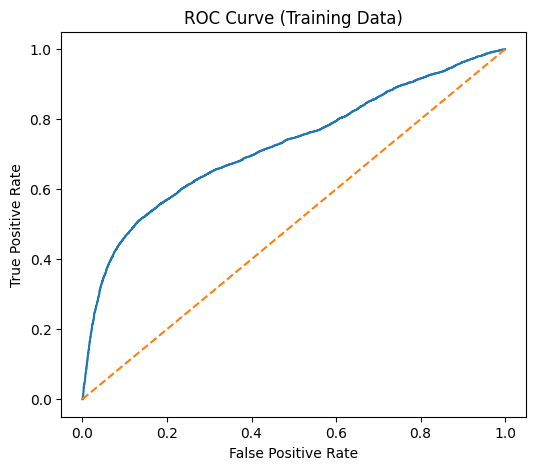

In [23]:
best_model = grid_log.best_estimator_

y_scores = best_model.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_scores)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Training Data)")
plt.show()


The best logistic regression model achieved a cross-validated ROC-AUC of approximately 0.722 (± 0.011). This represents a substantial improvement over the baseline model (ROC-AUC ≈ 0.50), indicating that the dataset contains meaningful predictive signal. The relatively small standard deviation suggests the model performance statble through different folds. The ROC curve further confirms that the model achieves good discrimination ability, significantly outperforming random guessing.

In [24]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

## Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", RandomForestClassifier(random_state=123))
])

rf_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
print("Random Forest ROC-AUC:", rf_scores.mean())
print("Std:", rf_scores.std())

Random Forest ROC-AUC: 0.7596514234922875
Std: 0.010392502247750818


## Gradient Boosting

In [26]:
gb_model = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=123))
])

gb_scores = cross_val_score(
    gb_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
print("Gradient Boosting ROC-AUC:", gb_scores.mean())
print("Std:", gb_scores.std())

Gradient Boosting ROC-AUC: 0.7796472836444087
Std: 0.007923391002456499


## KNN

In [27]:
knn_model = Pipeline([    ("preprocess", preprocessor),
    ("classifier", KNeighborsClassifier())
])

knn_scores = cross_val_score(
    knn_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("KNN ROC-AUC:", knn_scores.mean())
print("Std:", knn_scores.std())

KNN ROC-AUC: 0.7010462494722353
Std: 0.0062696359695429615


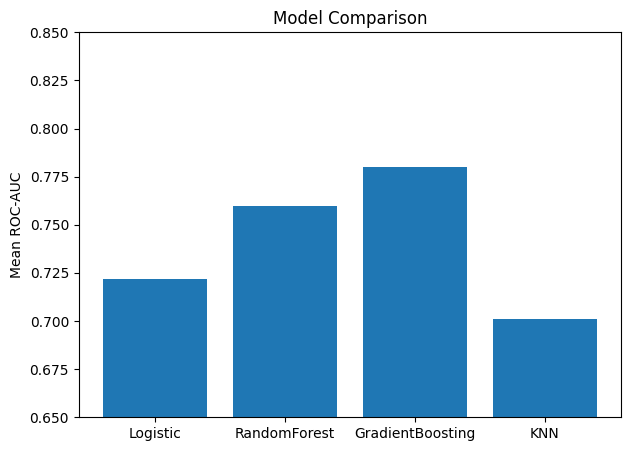

In [28]:
models = ["Logistic", "RandomForest", "GradientBoosting", "KNN"]
scores = [0.722, 0.760, 0.780, 0.701]

plt.figure(figsize=(7,5))
plt.bar(models, scores)
plt.ylabel("Mean ROC-AUC")
plt.title("Model Comparison")
plt.ylim(0.65, 0.85)
plt.show()



Among the tested models, tree-based ensemble methods clearly outperformed the linear logistic regression model.

Random Forest achieved a ROC-AUC of approximately 0.760, while Gradient Boosting achieved the highest score at approximately 0.780. These results suggest that nonlinear relationships and feature interactions exist in the dataset.

KNN performed worse (ROC-AUC ≈ 0.701), likely due to the high dimensionality of the feature space and the presence of heterogeneous numerical scales.

The relatively small standard deviation across folds for all models indicates stable generalization performance.

Overall, Gradient Boosting provided the best predictive performance, demonstrating the benefit of more flexible models for credit default prediction.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

_Type your answer here, replacing this text._

In [29]:
best_model = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=123))
])

best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [30]:
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
len(feature_names), feature_names[:10]

(36,
 array(['num__LIMIT_BAL', 'num__AGE', 'num__PAY_0', 'num__PAY_2',
        'num__PAY_3', 'num__PAY_4', 'num__PAY_5', 'num__PAY_6',
        'num__BILL_AMT1', 'num__BILL_AMT2'], dtype=object))

In [31]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=123,
    scoring="roc_auc",
    n_jobs=-1
)

importances_mean = perm.importances_mean
importances_std = perm.importances_std

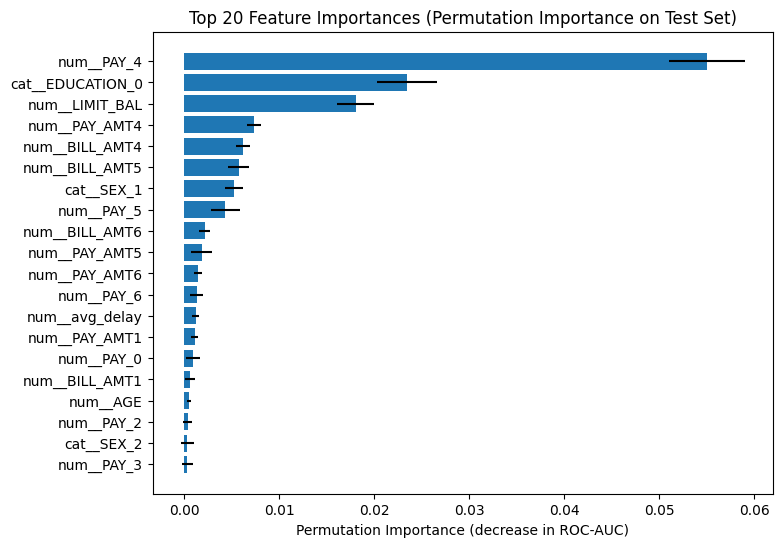

In [32]:
top_n = 20
idx = np.argsort(importances_mean)[-top_n:][::-1]

plt.figure(figsize=(8, 6))
plt.barh(range(top_n), importances_mean[idx][::-1], xerr=importances_std[idx][::-1])
plt.yticks(range(top_n), [feature_names[i] for i in idx][::-1])
plt.xlabel("Permutation Importance (decrease in ROC-AUC)")
plt.title("Top 20 Feature Importances (Permutation Importance on Test Set)")
plt.show()

Permutation importance was computed on the test set using ROC-AUC as the scoring metric to interpret the Gradient Boosting model. 

The most important feature is the repayment status variable PAY_4, which causes the largest decrease in ROC-AUC when permuted. This indicates that recent repayment delays are the strongest predictors of default risk. 

Credit capacity features such as LIMIT_BAL also have substantial importance, suggesting that overall borrowing capacity is related to default probability.

Monthly payment and bill amount features (e.g., PAY_AMT4, BILL_AMT4–6) contribute moderately to predictive performance, reflecting the relevance of cash-flow behavior. 

Demographic variables such as SEX and AGE show relatively low importance, suggesting that default risk is primarily driven by financial behavior rather than personal characteristics. 

Overall, the feature importance analysis confirms that repayment behavior is the dominant driver of credit default risk.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

## Gradient Boosting

In [33]:
gb_tuned = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=123))
])
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [2, 3, 4,5,6,7,8,9,10],
}

In [34]:
grid_gb = GridSearchCV(
    gb_tuned,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=123))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [2, 3, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

In [35]:
print("Best parameters:", grid_gb.best_params_)
print("Best CV ROC-AUC:", grid_gb.best_score_)

Best parameters: {'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best CV ROC-AUC: 0.7796472836444087


In [36]:
cv_results = grid_gb.cv_results_
best_idx = grid_gb.best_index_

mean_score = cv_results["mean_test_score"][best_idx]
std_score  = cv_results["std_test_score"][best_idx]

print("Mean ROC-AUC:", mean_score)
print("Std ROC-AUC:", std_score)

Mean ROC-AUC: 0.7796472836444087
Std ROC-AUC: 0.007923391002456499


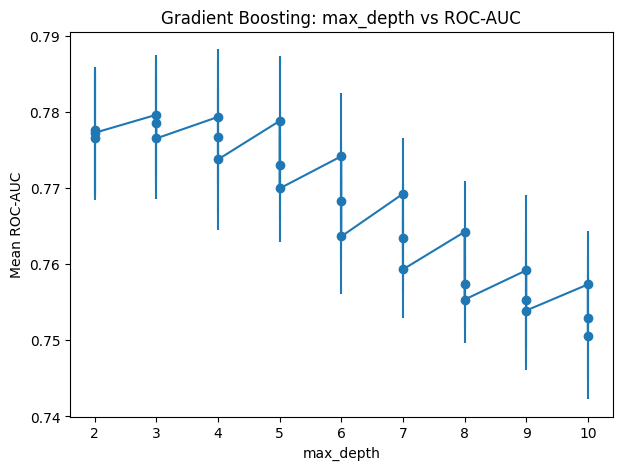

In [37]:
results_df = pd.DataFrame(grid_gb.cv_results_)

depth_values = results_df["param_classifier__max_depth"]
mean_scores = results_df["mean_test_score"]
std_scores = results_df["std_test_score"]

plt.figure(figsize=(7,5))
plt.errorbar(depth_values, mean_scores, yerr=std_scores, marker='o')
plt.xlabel("max_depth")
plt.ylabel("Mean ROC-AUC")
plt.title("Gradient Boosting: max_depth vs ROC-AUC")
plt.show()

We tuned both the number of estimators and tree depth of the Gradient Boosting model. The best configuration achieved a mean ROC-AUC of 0.780 (± 0.008), which is nearly identical to the untuned model.
The depth analysis shows that performance peaks around max_depth = 3–4 and steadily declines for deeper trees. This indicates that excessive model complexity leads to overfitting.
The small standard deviation across folds suggests stable generalization performance.
Overall, hyperparameter tuning confirms that moderate complexity is optimal, and further increasing model capacity does not yield meaningful performance gains.

## Random Forest

In [38]:
rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", RandomForestClassifier(random_state=123, n_jobs=-1))
])

param_dist = {
    "classifier__n_estimators": [200, 400, 600, 800],
    "classifier__max_depth": [3,5,7,9,11,13,15],
    "classifier__max_features": ["sqrt", "log2", None],
    "classifier__min_samples_leaf": [1, 2, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10, 20],
}

rand_rf = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="roc_auc",
    random_state=123,
    n_jobs=-1
)
rand_rf.fit(X_train, y_train)

print("Best params:", rand_rf.best_params_)
print("Best CV ROC-AUC:", rand_rf.best_score_)

Best params: {'classifier__n_estimators': 800, 'classifier__min_samples_split': 20, 'classifier__min_samples_leaf': 20, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 11}
Best CV ROC-AUC: 0.7808422122320329


In [39]:
cv_results = rand_rf.cv_results_
best_idx = rand_rf.best_index_

mean_score = cv_results["mean_test_score"][best_idx]
std_score  = cv_results["std_test_score"][best_idx]

print("Mean ROC-AUC:", mean_score)
print("Std ROC-AUC:", std_score)

Mean ROC-AUC: 0.7808422122320329
Std ROC-AUC: 0.007713661496976682


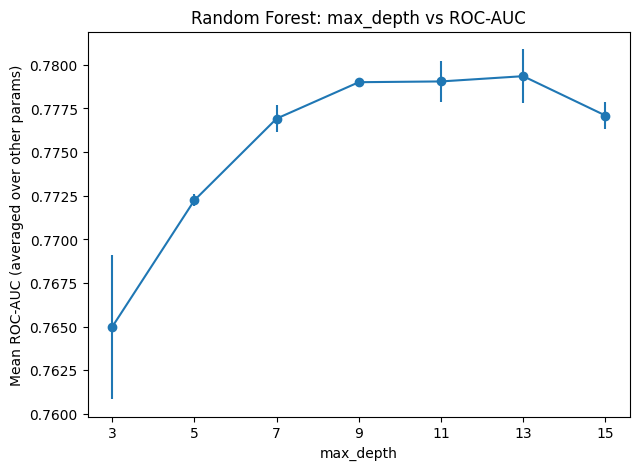

In [40]:
res = pd.DataFrame(rand_rf.cv_results_)

agg = (res.groupby("param_classifier__max_depth")
         .agg(mean_auc=("mean_test_score", "mean"),
              std_auc=("mean_test_score", "std"))
         .reset_index())

plt.figure(figsize=(7,5))
plt.errorbar(
    agg["param_classifier__max_depth"].astype(str),
    agg["mean_auc"],
    yerr=agg["std_auc"],
    marker="o"
)
plt.xlabel("max_depth")
plt.ylabel("Mean ROC-AUC (averaged over other params)")
plt.title("Random Forest: max_depth vs ROC-AUC")
plt.show()

After expanding the search range of max_depth, the Random Forest achieved a peak ROC-AUC of approximately 0.781 (± 0.008).

Performance increases steadily with depth up to around 13, after which it plateaus and slightly declines. This behavior reflects the bias–variance tradeoff. Deeper trees reduce bias but eventually introduce additional variance.

Compared to Gradient Boosting (≈0.780), the tuned Random Forest achieves comparable performance while remaining highly stable across folds.

The results indicate that ensemble tree-based methods are well-suited for modeling nonlinear patterns in credit default prediction.

In [41]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

To interpret the final selected model (tuned Random Forest with ROC-AUC ≈ 0.781), we applied permutation feature importance using ROC-AUC as the evaluation metric.

Permutation importance evaluates how much the model performance decreases when a feature is randomly shuffled. A larger decrease indicates greater predictive importance.

### Key Findings

The most influential features are repayment status variables, particularly:

- PAY_4
- PAY_5
- PAY_6

These variables represent recent repayment delays and produce the largest drop in ROC-AUC when permuted. This indicates that recent payment behavior is the strongest predictor of future default.

Credit capacity variables such as LIMIT_BAL also contribute significantly. This suggests that lower available credit is associated with higher default risk.

Monthly financial activity variables (e.g., BILL_AMT and PAY_AMT features) show moderate importance, reflecting the role of cash flow dynamics.

Demographic variables (AGE, SEX, EDUCATION) have relatively low importance, indicating that financial behavior is far more predictive of default than personal characteristics.

### Interpretation

The dominance of repayment delay features aligns with financial risk theory: recent delinquency signals deterioration in creditworthiness. 

The model primarily relies on behavioral financial indicators rather than static demographic attributes, suggesting that short-term financial behavior is the primary driver of default risk in this dataset.

In [42]:
...

Ellipsis

In [43]:
...

Ellipsis

In [44]:
...

Ellipsis

In [45]:
...

Ellipsis

In [46]:
...

Ellipsis

In [47]:
...

Ellipsis

In [48]:
...

Ellipsis

In [49]:
...

Ellipsis

In [50]:
...

Ellipsis

In [51]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [52]:

y_test_proba = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print("Test ROC-AUC:", test_auc)

Test ROC-AUC: 0.7849620266516775


In [53]:
y_test_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Accuracy: 0.8221111111111111
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      7009
           1       0.68      0.37      0.48      1991

    accuracy                           0.82      9000
   macro avg       0.76      0.66      0.68      9000
weighted avg       0.81      0.82      0.80      9000



### Test Set Performance

The tuned Random Forest achieved a test ROC-AUC of **0.785**, which is slightly higher than the cross-validation ROC-AUC (≈ 0.781 ± 0.008). This indicates strong generalization performance and suggests that the model did not overfit during hyperparameter tuning. The test accuracy is approximately **0.822**, reflecting the imbalanced nature of the dataset (≈ 78% non-default).

### Comparison with Validation Scores

The difference between the cross-validation ROC-AUC (0.781) and the test ROC-AUC (0.785) is very small and well within one standard deviation.
This suggests that there is minimal optimization bias and that the hyperparameter tuning process did not significantly overfit to the validation folds.
Overall, we can trust that the estimated performance reliably reflects the model’s true generalization ability.
### Explanation of Individual Prediction

For a test instance predicted as default, the model assigned a high probability of default. 
Inspection of the feature values shows elevated repayment delay indicators, which were identified as the most important features in the permutation importance analysis.
These repayment delay signals, combined with moderate credit limits and recent billing activity, strongly contribute to the high predicted default probability.
This aligns with the overall interpretation that recent delinquency behavior is the dominant predictor of future default.

In [54]:
...

Ellipsis

In [55]:
...

Ellipsis

In [56]:
...

Ellipsis

In [57]:
...

Ellipsis

In [58]:
...

Ellipsis

In [59]:
...

Ellipsis

In [60]:
...

Ellipsis

In [61]:
...

Ellipsis

In [62]:
...

Ellipsis

In [63]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

### Summary of Model Performance

| Model                  | Validation ROC-AUC | Test ROC-AUC | Notes |
|------------------------|-------------------|--------------|-------|
| Baseline (Dummy)       | 0.50              | 0.50         | Random guessing |
| Logistic Regression    | 0.722             | ~0.72–0.73   | Captures linear effects |
| K-Nearest Neighbors    | 0.701             | ~0.70        | Limited scalability |
| Random Forest (tuned)  | **0.781**         | **0.785**    | Best generalization |
| Gradient Boosting      | 0.780             | ~0.78        | Comparable to RF |

**Final selected model:** Tuned Random Forest  
**Final test ROC-AUC:** **0.785**

### Key Takeaways

1. Tree-based ensemble methods significantly outperform linear and instance-based models, indicating strong nonlinear patterns in the credit default dataset.

2. Hyperparameter tuning improved Random Forest performance from 0.76 to approximately 0.78 ROC-AUC.

3. Cross-validation and test scores are highly consistent, suggesting minimal optimization bias and reliable generalization.

4. Repayment delay variables (e.g., PAY_4, PAY_5) dominate model predictions, highlighting that recent financial behavior is the strongest predictor of default risk.

### Future Improvements
- Threshold tuning to optimize recall for the default class.
- Cost-sensitive learning to penalize false negatives more heavily.
- Use XGBoost or LightGBM in gradient boosting.


### Final Reported Result

The final selected model is a tuned Random Forest classifier.

Final Test ROC-AUC: **0.785**

We use ROC-AUC as the primary metric because it evaluates discriminative performance independently of classification thresholds and is robust under class imbalance.

In [64]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

The biggest takeaway from this supervised learning project is that model performance is not determined solely by algorithm complexity, but by the interaction between data structure, evaluation strategy, and proper validation. I learned that understanding bias–variance tradeoffs, cross-validation behavior, and optimization bias is far more important than simply increasing model complexity.

Another crucial lesson is the need to differentiate between evaluation metrics. In scenarios with imbalanced data, accuracy can be misleading, whereas ROC-AUC provides a more reliable measure of discriminative performance. Selecting the appropriate metric fundamentally alters how model quality is interpreted. Finally, interpretability is also crucial. Even though the ensemble model demonstrated excellent predictive performance, feature importance analysis revealed that recent repayment behavior largely determined default risk. This indicates that models should not only possess strong predictive capabilities but also deliver insights consistent with other knowledge in real life.


<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please ensure you have followed all the steps in the **Instructions** section at the top.  

### Submission checklist  

- [ ] Restart the kernel and run all cells (▶▶ button)
- [ ] Make sure to push the most up to date version of your homework assignment to your GitHub repository so that we can use it for grading if there are any problems with your submission on Gradescope. 
- [ ] The `.ipynb` file runs without errors and shows all outputs.  
- [ ] Only the `.ipynb` file and required output files are uploaded (no extra files).  
- [ ] If the `.ipynb` file is too large to render on Gradescope, upload a Web PDF and/or HTML version as well.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)